# Polished EDA figures (thesis-ready)

A self-contained notebook that regenerates the three publication-quality
exploratory figures for the CaMCheX / CXR-LT dataset, using the shared look in
[`eda_style.py`](./eda_style.py). It does **not** modify any of the original
examination notebooks — the plotting logic lives in
[`make_eda_figures.py`](./make_eda_figures.py) and is reused here.

| Figure | What it shows |
|---|---|
| 1 | Long-tailed label distribution (prevalence + log-scale counts, by frequency tier) |
| 2 | Label structure: Pearson correlation and conditional co-occurrence P(B \| A) |
| 3 | Prior-study viability: coverage, follow-up time gaps, prior-label informativeness |

Each cell writes a 300‑dpi PNG (plus a vector PDF) to `report/img/eda/` and
displays it inline.

In [1]:
from pathlib import Path
from IPython.display import Image, display

import make_eda_figures as mk  # reuses the shared, tested plotting logic
from eda_style import apply_style

apply_style()

# Resolve paths from the module location, so the notebook works regardless of cwd.
REPO = Path(mk.__file__).resolve().parents[2]
DATA_DIR = REPO / "data" / "data-camchex"
OUT_DIR = REPO / "report" / "img" / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("data:", DATA_DIR)
print("out :", OUT_DIR)

data: /sessions/eloquent-kind-davinci/mnt/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/data/data-camchex
out : /sessions/eloquent-kind-davinci/mnt/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/report/img/eda


## Load the prepared dataset

Concatenates the train / development / test splits from
`data/data-camchex/03_mimic_*.csv` and coerces the 26 CXR-LT label columns to
integers.

In [2]:
df = mk.load(DATA_DIR)
print(f"{len(df):,} image rows  ·  {df['study_id'].nunique():,} studies")
df[["split", "study_id", "PreviousStudy", "ViewPosition"]].head()

339,745 image rows  ·  206,873 studies


,split,study_id,PreviousStudy,ViewPosition
0,train,50000014,NaN,AP
1,train,50000052,50779042.0,AP
2,train,50000186,NaN,PA
3,train,50000186,NaN,LATERAL
4,train,50000635,NaN,PA


## Figure 1 — Long-tailed label distribution

Per-class prevalence (left) and positive-image counts on a log axis (right),
color-coded by CXR-LT frequency tier. The log panel makes the >100× imbalance
between head and tail findings legible.

  fig1: fig1_label_longtail.png  (imbalance ratio 162x)


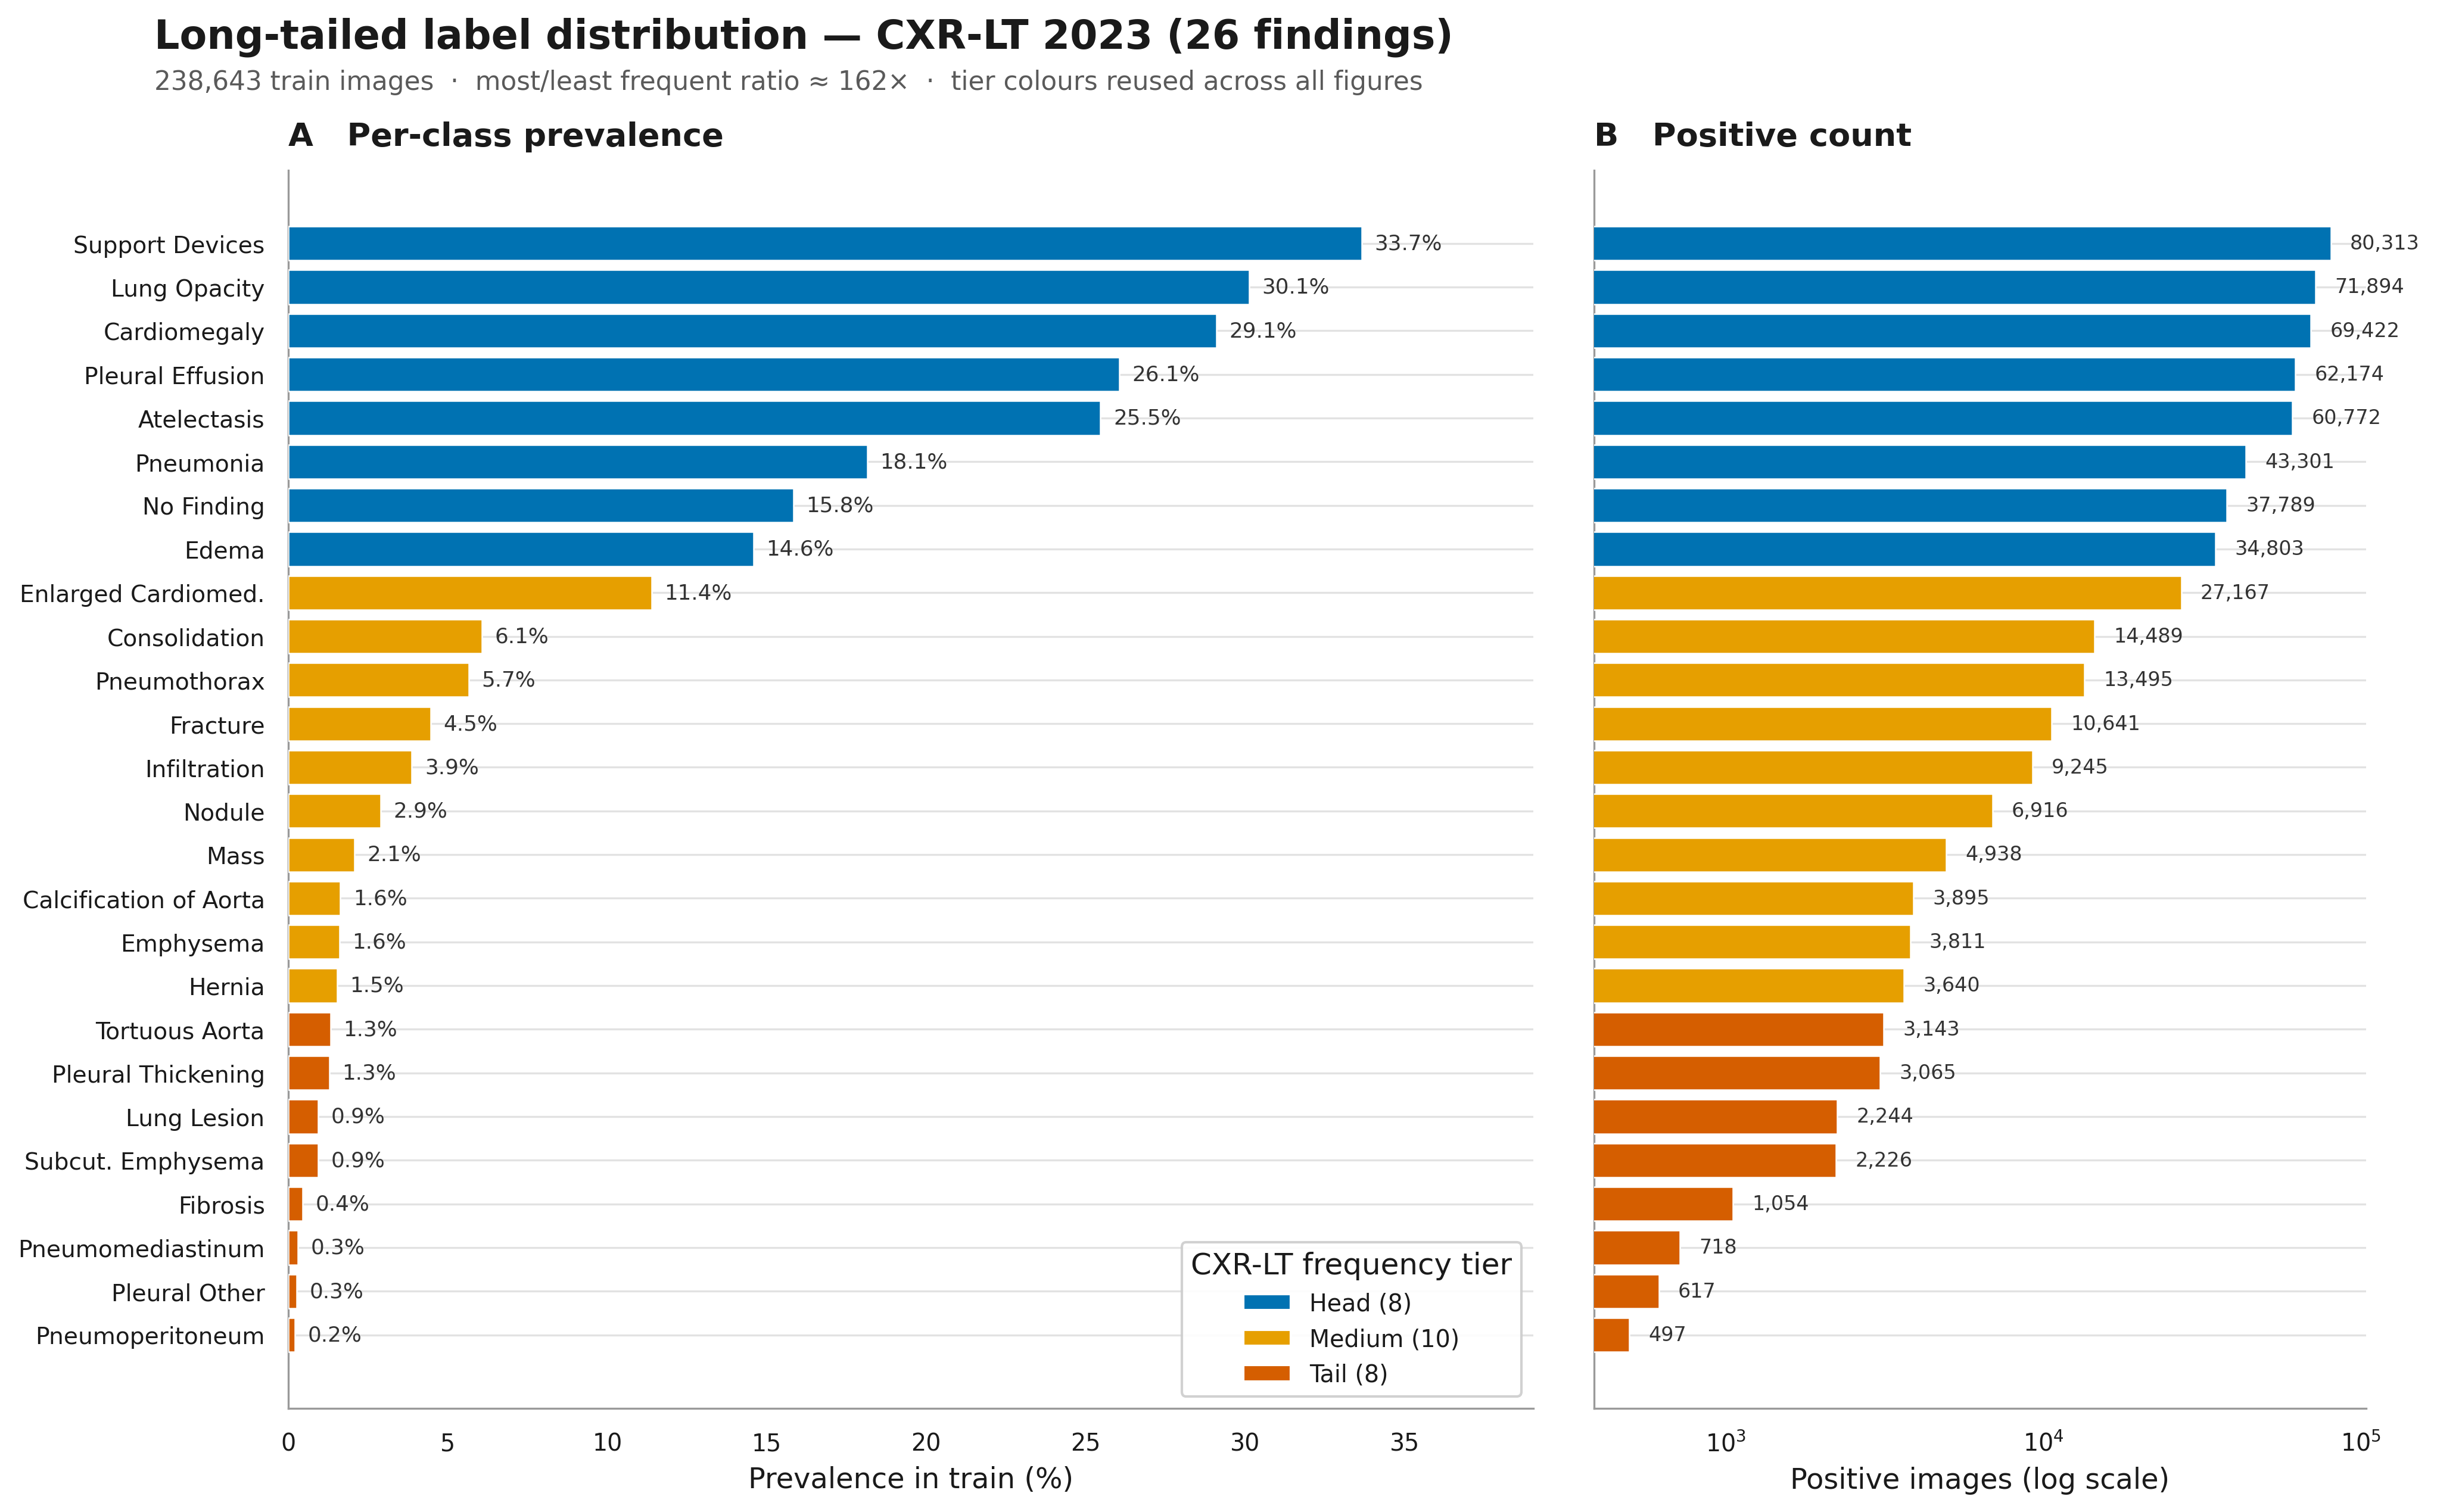

In [3]:
p1 = OUT_DIR / "fig1_label_longtail.png"
mk.fig_longtail(df, p1)
display(Image(filename=str(p1)))

## Figure 2 — Label co-occurrence structure

Left: Pearson correlation between labels. Right: conditional co-occurrence
P(B | A). Rows and columns are ordered by prevalence and tick labels are
colored by tier.

  fig2: fig2_label_structure.png


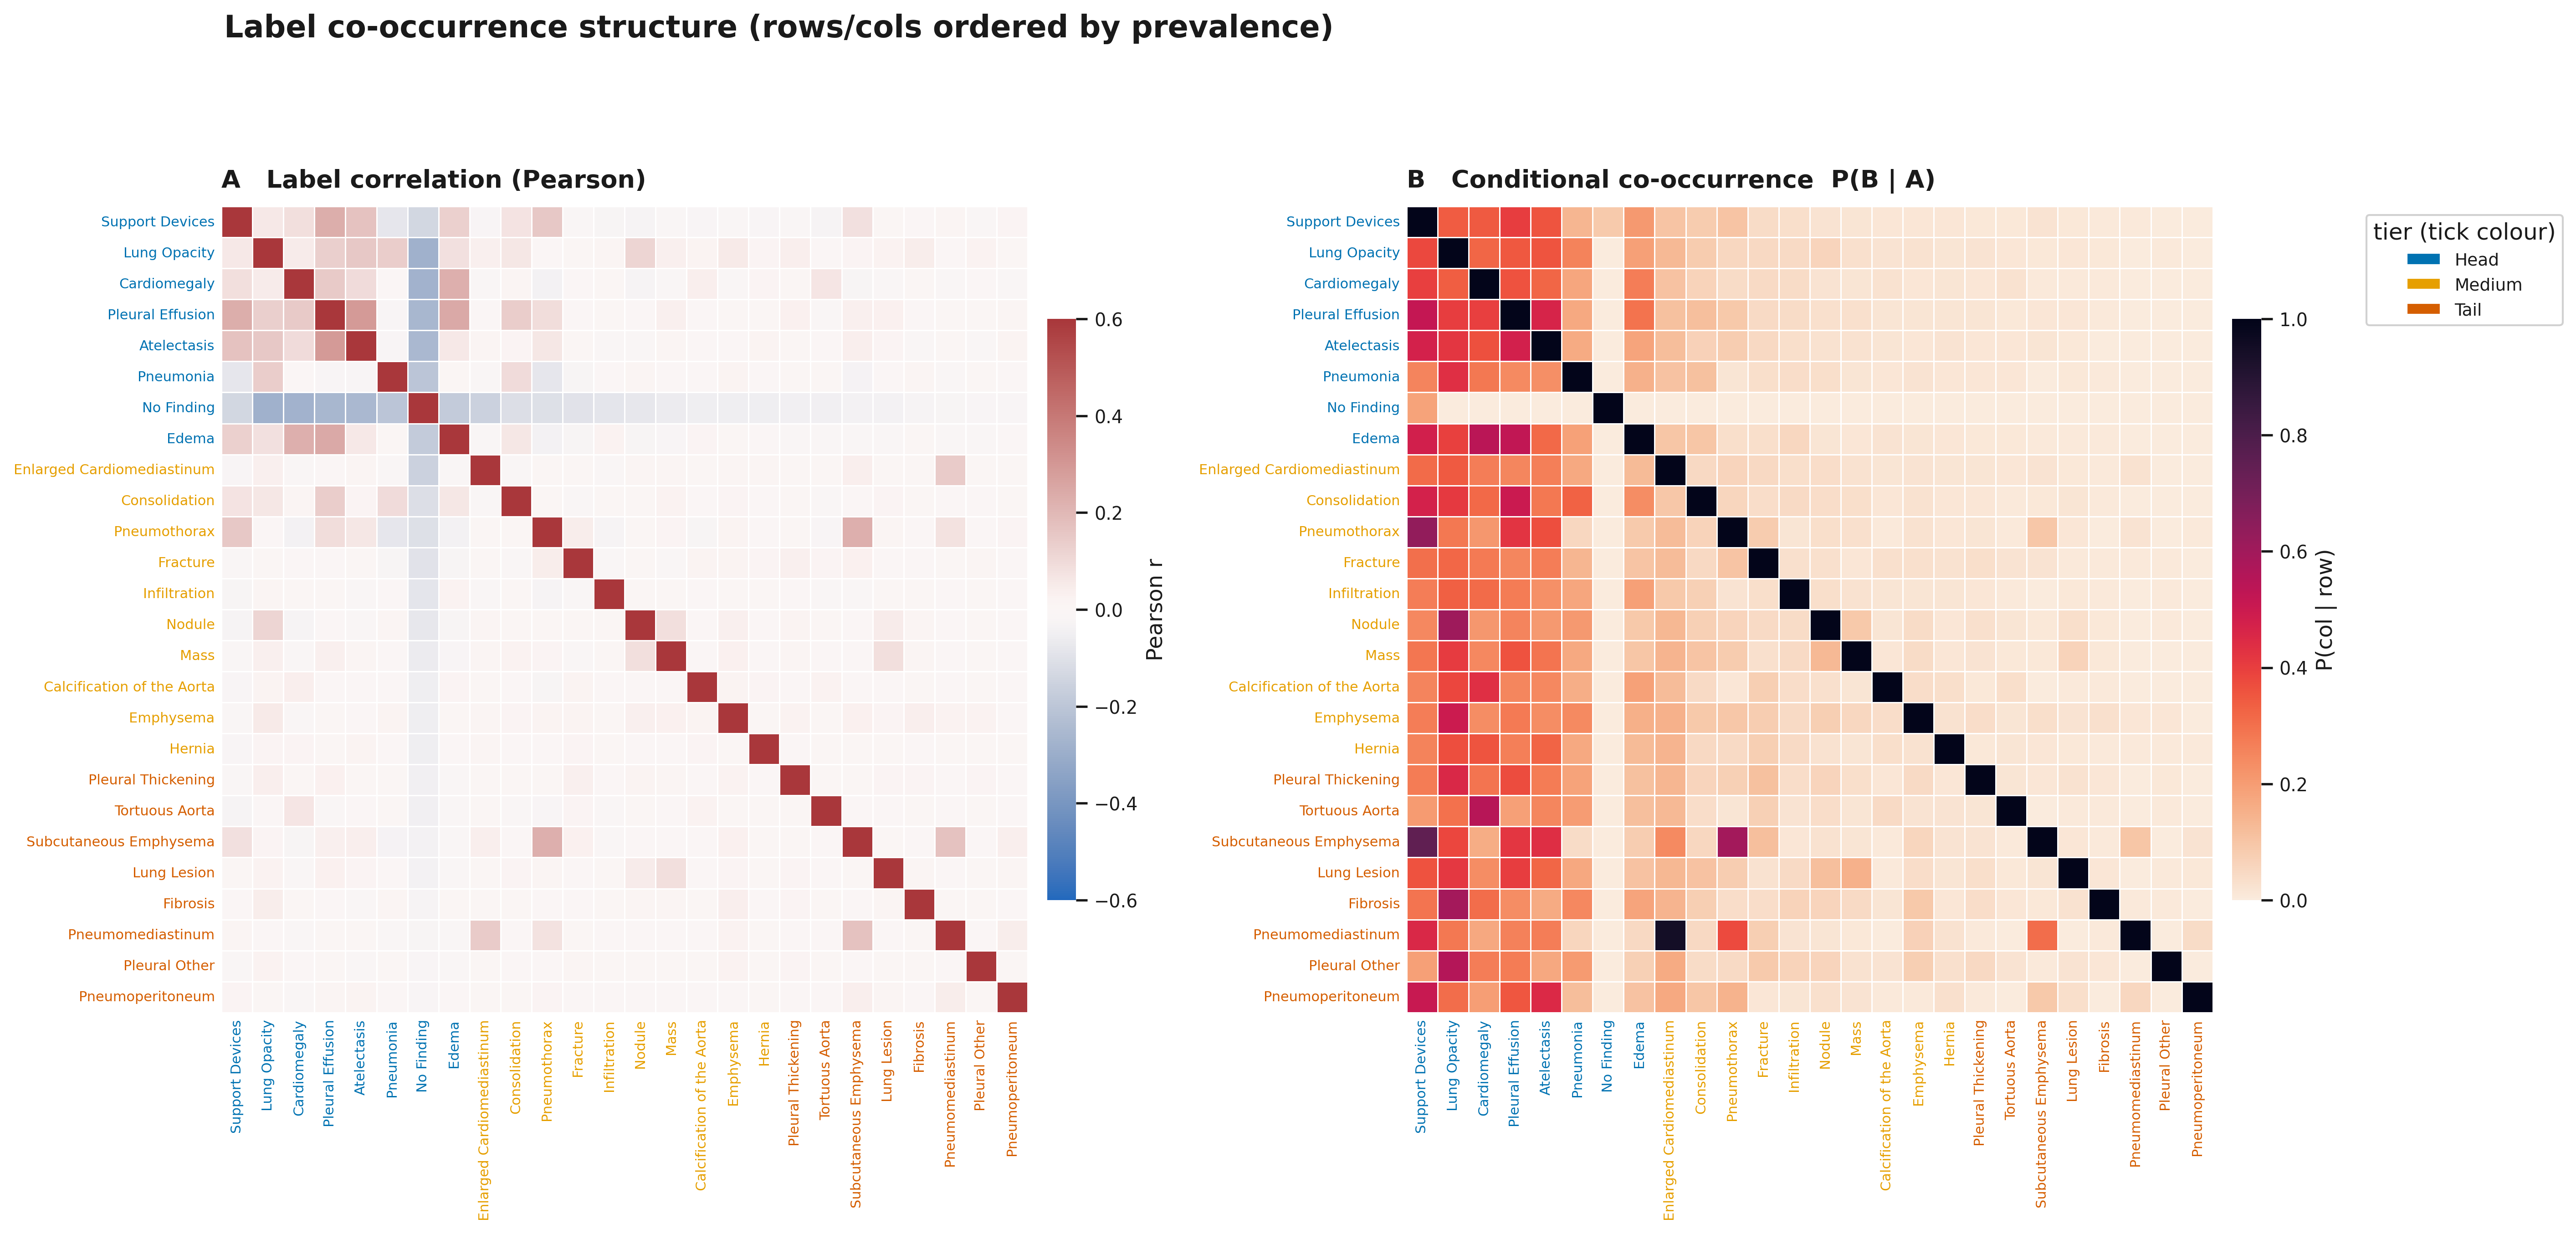

In [4]:
p2 = OUT_DIR / "fig2_label_structure.png"
mk.fig_structure(df, p2)
display(Image(filename=str(p2)))

## Figure 3 — Prior-study viability

Prior coverage by split, follow-up time-gap distribution, and a dumbbell plot
of how much a finding's prior label shifts its current probability (predictive
lift), sorted by lift.

  fig3: fig3_prior_study.png  (prior coverage 71%)


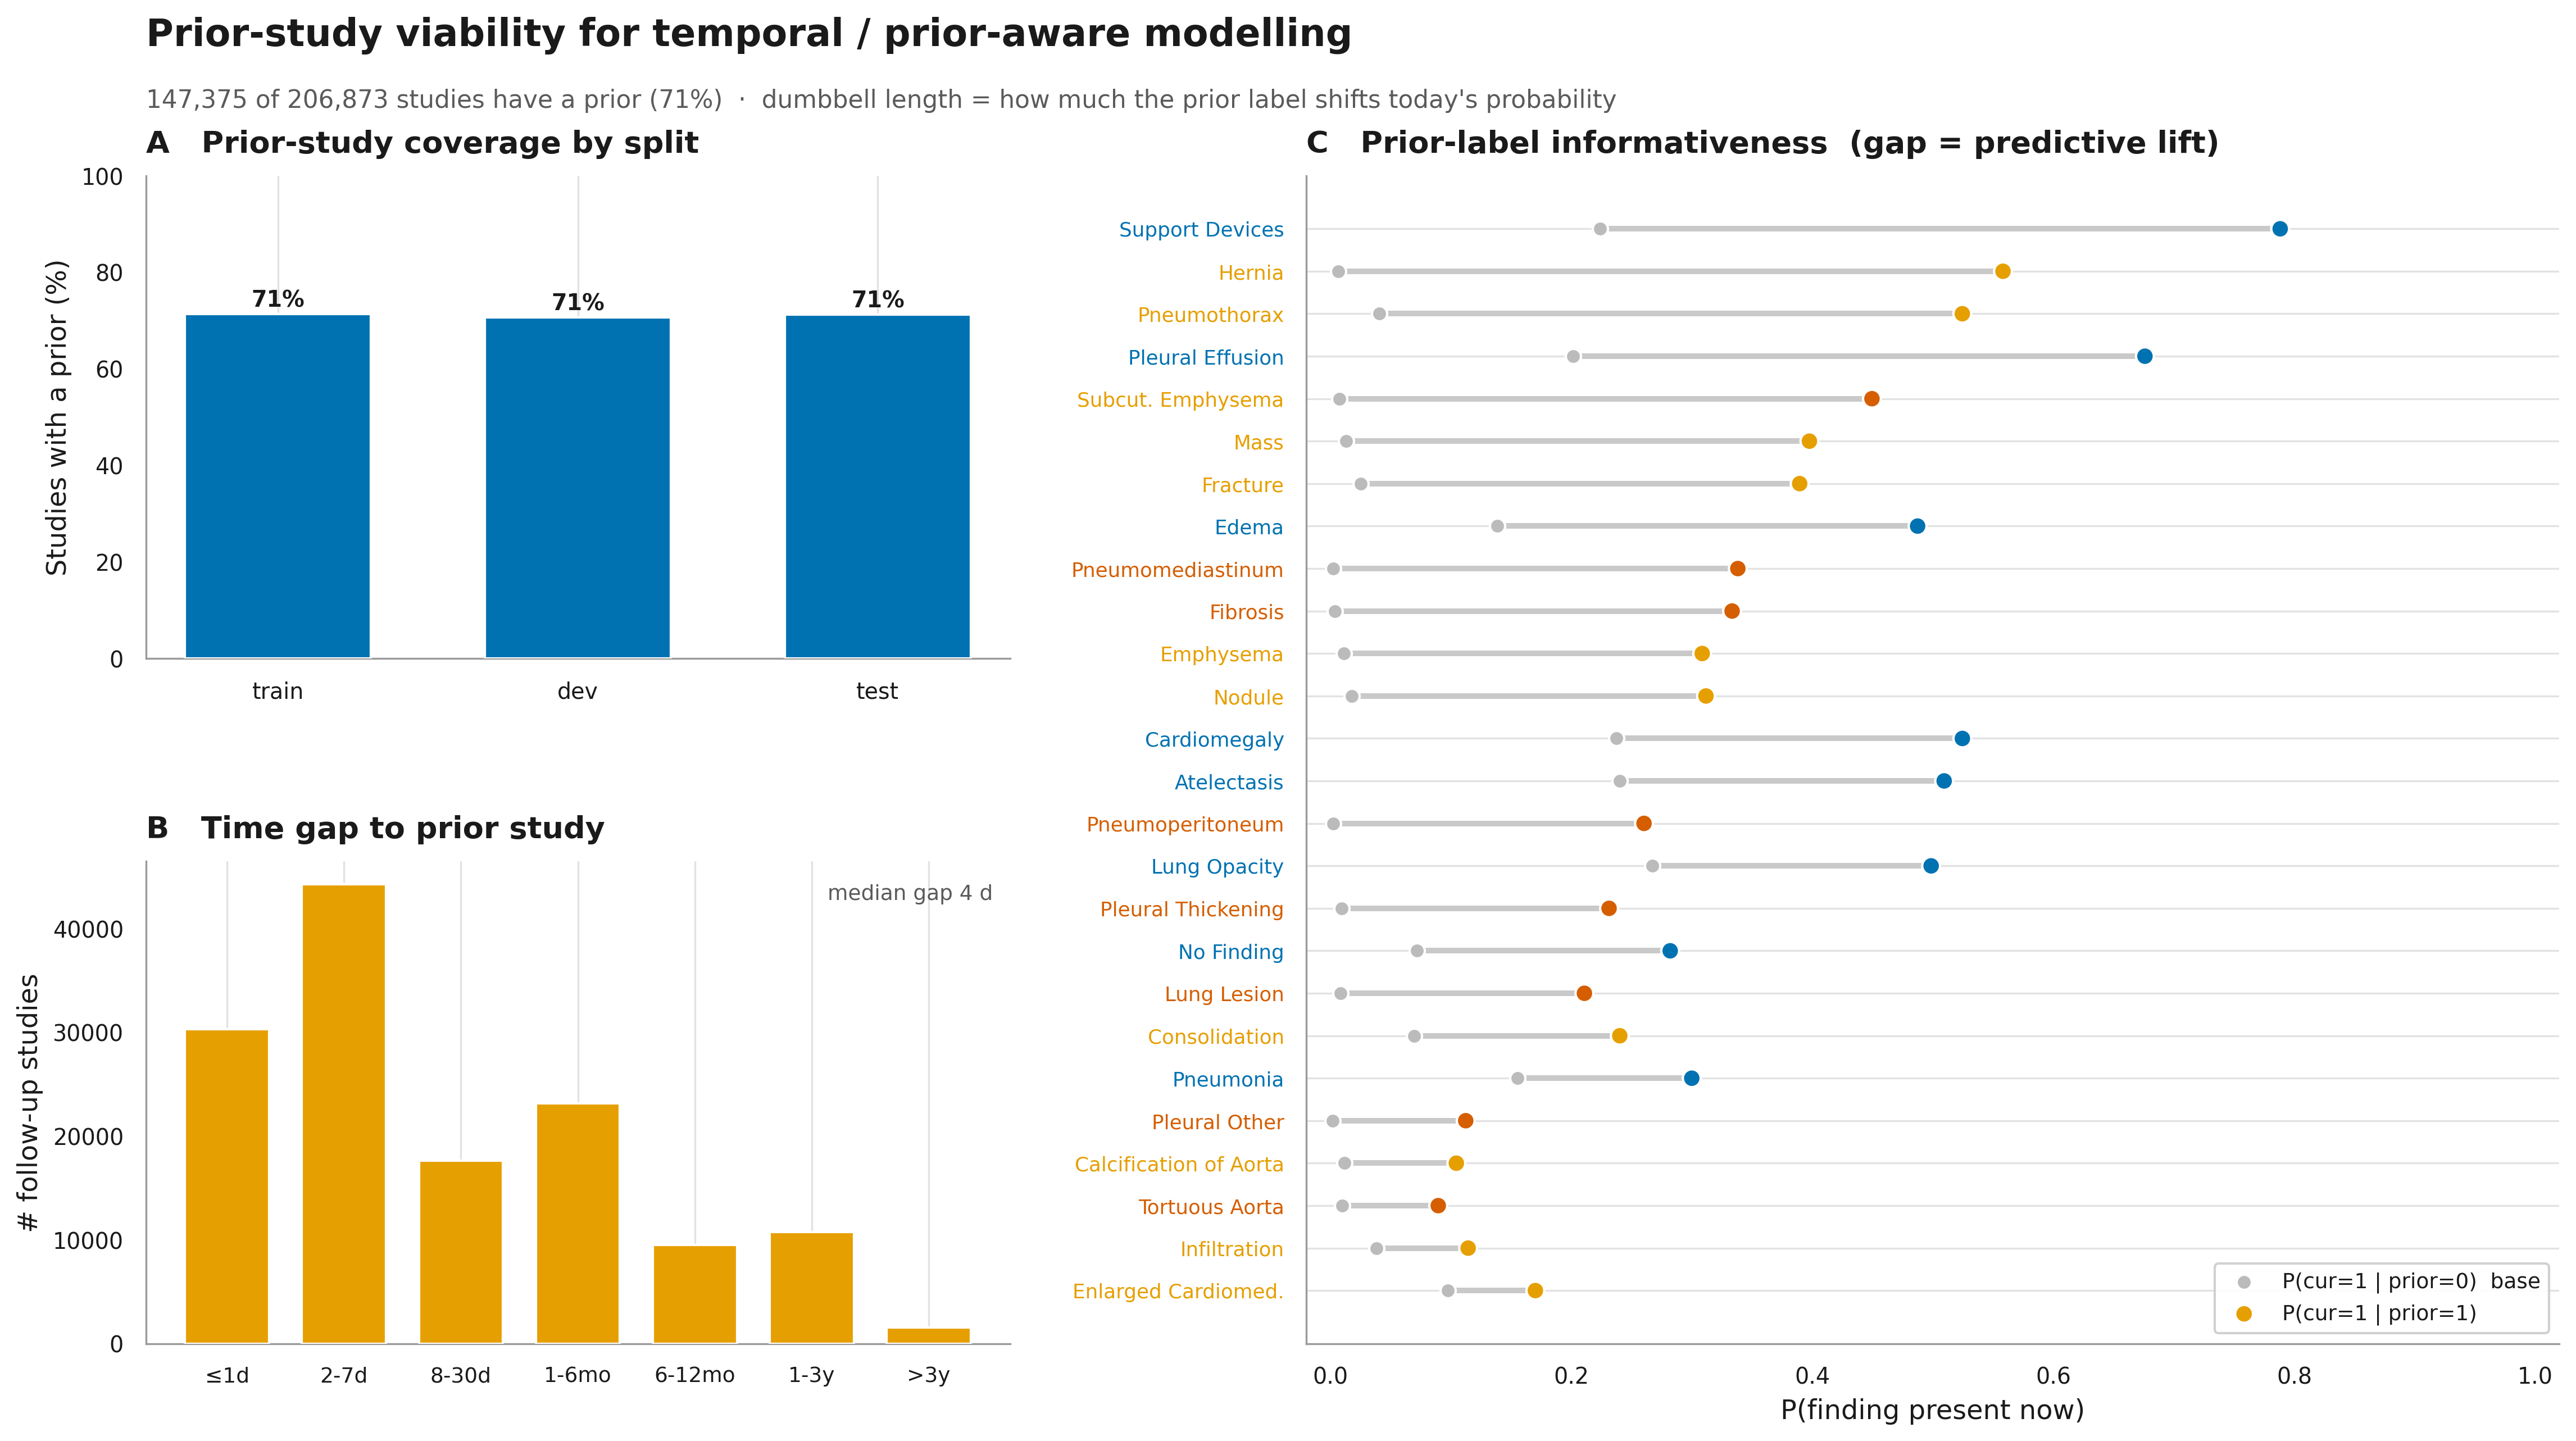

In [5]:
p3 = OUT_DIR / "fig3_prior_study.png"
mk.fig_prior(df, p3)
display(Image(filename=str(p3)))

## Reusing the style elsewhere

To give any existing notebook the same look without changing its plots, add at
the top:

```python
from eda_style import apply_style, TIER_COLORS, tier_of, despine, save
apply_style()
```

`apply_style()` is a drop-in replacement for `sns.set_theme(style="whitegrid")`.
You can also regenerate every figure from the command line:

```bash
python data/00-examine-data/make_eda_figures.py
```